#  RAG Chunk Size Evaluator — Fully Local with Ollama

**No OpenAI API key needed.** Runs entirely on your machine using Ollama.

### Prerequisites
1. Install Ollama: https://ollama.com/download
2. Pull the models you need:
```bash
ollama pull phi4-mini       # for answering
ollama pull phi4-mini        # also used for evaluation
```
3. Make sure Ollama is running (`ollama serve` or the desktop app)


##  Install Dependencies

In [2]:
!pip install llama-index \
             llama-index-llms-ollama \
             llama-index-embeddings-ollama \
             nest_asyncio

##  Imports

In [3]:
import nest_asyncio
import random
import time
import os

nest_asyncio.apply()

from llama_index.core import VectorStoreIndex, SimpleDirectoryReader, Settings
from llama_index.core.prompts import PromptTemplate
from llama_index.core.evaluation import (
    DatasetGenerator,
    FaithfulnessEvaluator,
    RelevancyEvaluator
)
from llama_index.llms.ollama import Ollama
from llama_index.embeddings.ollama import OllamaEmbedding

print("✅ Imports successful!")

✅ Imports successful!


##  Configure Ollama Models

Change `ANSWERING_MODEL` and `EVAL_MODEL` to any model you have pulled in Ollama.

Recommended:
- Fast machine: `llama3.2` or `mistral`
- Slower/older machine: `phi3` or `gemma:2b`

Check what you have: run `ollama list` in terminal.

In [14]:
OLLAMA_BASE_URL = "http://localhost:11434"  # default Ollama URL
ANSWERING_MODEL = "phi4-mini"
EVAL_MODEL      = "phi4-mini"
EMBED_MODEL     = "phi4-mini"          # used for vector embeddings

# LLM for answering queries
answer_llm = Ollama(
    model=ANSWERING_MODEL,
    base_url=OLLAMA_BASE_URL,
    request_timeout=600.0
)

# LLM for evaluation (can be same model)
eval_llm = Ollama(
    model=EVAL_MODEL,
    base_url=OLLAMA_BASE_URL,
    request_timeout=600.0
)

# Embedding model
embed_model = OllamaEmbedding(
    model_name=EMBED_MODEL,
    base_url=OLLAMA_BASE_URL
)

# Set global defaults
Settings.llm = eval_llm
Settings.embed_model = embed_model

# Quick sanity check
test = answer_llm.complete("Say 'Ollama is working' in 5 words.")
print("🦙 Ollama check:", test.text.strip())

🦙 Ollama check: Ollama processes data efficiently.


## 📂 Load Documents

Place your `.txt` or `.pdf` files inside a `data/` folder next to this notebook.

Download sample docs from the cell below, or drop in your own files.

In [ ]:
# Create data directory if it doesn't exist
os.makedirs("data", exist_ok=True)

# --- Sample documents (copy-paste friendly) ---
# If you downloaded the .txt files from the companion section, they go in ./data/
# Otherwise this cell creates 3 small sample docs automatically:

sample_docs = {
    "data/neural_networks.txt": """Neural Networks and Deep Learning

A neural network is a computational model inspired by the structure of the human brain.
It consists of layers of interconnected nodes, called neurons, that process information.
The three main types of layers are: input layer, hidden layers, and output layer.

Deep learning refers to neural networks with many hidden layers. These networks can learn
hierarchical representations of data. For example, in image recognition, early layers
detect edges, middle layers detect shapes, and later layers detect objects.

Training a neural network involves forward propagation (computing predictions) and
backpropagation (adjusting weights based on errors). The loss function measures how
wrong the predictions are, and gradient descent minimizes this loss.

Activation functions like ReLU, sigmoid, and tanh introduce non-linearity, allowing
networks to learn complex patterns. Without activation functions, a neural network
would simply be a linear transformation regardless of depth.

Overfitting occurs when a model memorizes training data but fails on new data.
Techniques like dropout, regularization, and data augmentation help prevent overfitting.
Batch normalization stabilizes training by normalizing layer inputs.

Convolutional Neural Networks (CNNs) are specialized for grid-like data such as images.
Recurrent Neural Networks (RNNs) are designed for sequential data like text and speech.
Transformers use attention mechanisms and have become dominant in NLP tasks.
""",
    "data/transformers.txt": """Transformers and Attention Mechanisms

The Transformer architecture was introduced in the 2017 paper "Attention Is All You Need"
by Vaswani et al. It revolutionized natural language processing by replacing recurrent
networks with self-attention mechanisms.

Self-attention allows each token in a sequence to attend to all other tokens,
capturing long-range dependencies efficiently. The attention score between two tokens
determines how much one token should influence the representation of another.

Multi-head attention runs several attention operations in parallel, each learning
different types of relationships. The outputs are concatenated and projected to form
the final attention output.

Positional encoding is added to token embeddings so the model knows the order of tokens.
Without it, the Transformer would treat input as a bag of words with no order.

The Transformer has an encoder-decoder structure. The encoder processes the input
sequence and the decoder generates the output sequence. BERT uses only the encoder
while GPT uses only the decoder.

Large Language Models (LLMs) like GPT-4 and LLaMA are massive Transformer decoders
trained on trillions of tokens. They predict the next token given all previous tokens,
a task called causal language modeling.

Fine-tuning adapts a pre-trained model to specific tasks. RLHF (Reinforcement Learning
from Human Feedback) aligns LLMs with human preferences, making them more helpful
and less harmful.
""",
    "data/rag.txt": """Retrieval Augmented Generation (RAG)

RAG is a technique that enhances LLM responses by retrieving relevant information
from an external knowledge base before generating an answer. This grounds the model
in factual, up-to-date information beyond its training data.

The RAG pipeline has two main phases: indexing and retrieval. During indexing,
documents are split into chunks, converted to embeddings, and stored in a vector database.
During retrieval, the user query is embedded and similar chunks are fetched.

Chunk size is a critical hyperparameter in RAG. Smaller chunks (128-256 tokens) are
more precise but may lack context. Larger chunks (512-1024 tokens) provide more
context but may include irrelevant information.

Chunk overlap ensures continuity between chunks. A 20% overlap means consecutive
chunks share some content, preventing information loss at boundaries.

Vector similarity search compares embeddings using cosine similarity or dot product.
The top-k most similar chunks are retrieved and passed to the LLM as context.

Faithfulness measures whether the generated answer is supported by retrieved context.
Relevancy measures whether the retrieved context is appropriate for the query.
Together they form the core evaluation metrics for RAG systems.

Advanced RAG techniques include: HyDE (Hypothetical Document Embeddings), query
rewriting, re-ranking retrieved chunks, and parent-child chunk retrieval strategies.
These improve retrieval quality beyond naive similarity search.
"""
}

for path, content in sample_docs.items():
    if not os.path.exists(path):
        with open(path, "w") as f:
            f.write(content)
        print(f"📄 Created: {path}")
    else:
        print(f"✅ Already exists: {path}")

print("\n📂 data/ folder ready!")

In [5]:
documents = SimpleDirectoryReader("data").load_data()
print(f"✅ Loaded {len(documents)} document(s)")
for doc in documents:
    print(f"   - {doc.metadata.get('file_name', 'unknown')} ({len(doc.text)} chars)")

✅ Loaded 3 document(s)
   - neural_networks.txt (1966 chars)
   - rag.txt (2133 chars)
   - transformers.txt (2025 chars)


##  Generate Evaluation Questions

We use the LLM to auto-generate questions from the documents.

In [6]:
NUM_EVAL_QUESTIONS = 6  # keep low for local models (each question = 1 LLM call)

# Use all docs for question generation
Settings.llm = eval_llm
data_generator = DatasetGenerator.from_documents(documents)
all_questions = data_generator.generate_questions_from_nodes()

# Sample k questions
k = min(NUM_EVAL_QUESTIONS, len(all_questions))
eval_questions = random.sample(all_questions, k)

print(f"✅ Generated {len(all_questions)} questions, selected {k}:")
for i, q in enumerate(eval_questions, 1):
    print(f"  {i}. {q}")

C:\Users\Yash\AppData\Local\Programs\Python\Python311\Lib\site-packages\llama_index\core\evaluation\dataset_generation.py:201: DeprecationWarning: Call to deprecated class DatasetGenerator. (Deprecated in favor of `RagDatasetGenerator` which should be used instead.)
  return cls(


✅ Generated 32 questions, selected 6:
  1. What year was the Transformer architecture introduced, and by whom?
  2. Define what a 'context window' means in Transformer models; also provide an example of how its size has evolved from early implementations up until recent versions supporting over 100k tokens at once for processing sequences or documents.
  3. Describe an advantage of using Transformers over other architectures for NLP tasks based on what you learned from this context information.
  4. Can you describe a scenario where it would make sense to use Convolutional Neural Networks (CNNs) versus Recurrent Neural Networks (RNNs)?
  5. Discuss the importance of ANN search and name at least two vector databases suitable for this purpose as part of a hybrid search approach combining both dense vectors and sparse keyword indexing methods like BM25.
  6. What are Large Language Models (LLMs), such as GPT-4 and LLaMA designed for, according to the context provided? Describe this proces

C:\Users\Yash\AppData\Local\Programs\Python\Python311\Lib\site-packages\llama_index\core\evaluation\dataset_generation.py:297: DeprecationWarning: Call to deprecated class QueryResponseDataset. (Deprecated in favor of `LabelledRagDataset` which should be used instead.)
  return QueryResponseDataset(queries=queries, responses=responses_dict)


##  Set Up Evaluators

In [7]:
# Faithfulness: does the answer come from the context?
faithfulness_evaluator = FaithfulnessEvaluator(llm=eval_llm)

# Custom prompt — clearer YES/NO instructions for smaller local models
faithfulness_prompt = PromptTemplate("""
Does the following information appear in the context? Answer only YES or NO.

Examples:
Information: Apple pie is double-crusted.
Context: Apple pie is generally double-crusted, with pastry above and below.
Answer: YES

Information: Apple pies taste bad.
Context: Apple pie is a fruit pie with apples as the main filling.
Answer: NO

Information: {query_str}
Context: {context_str}
Answer:
""")

faithfulness_evaluator.update_prompts({"your_prompt_key": faithfulness_prompt})

# Relevancy: is the context relevant to the query?
relevancy_evaluator = RelevancyEvaluator(llm=eval_llm)

print("✅ Evaluators ready!")

✅ Evaluators ready!


##  Evaluation Function

In [20]:
async def evaluate_chunk_size(chunk_size, eval_questions):
    print(f"\n🔍 Testing chunk_size={chunk_size}...")

    Settings.llm = answer_llm
    Settings.embed_model = embed_model
    Settings.chunk_size = chunk_size
    Settings.chunk_overlap = chunk_size // 5

    vector_index = VectorStoreIndex.from_documents(documents)
    query_engine = vector_index.as_query_engine(similarity_top_k=3)

    total_time = 0
    num_questions = len(eval_questions)
    stored_responses = []  # ← store responses for eval later

    for i, question in enumerate(eval_questions, 1):
        print(f"  Q{i}/{num_questions}: {question[:60]}...")

        start = time.time()
        response = query_engine.query(question)
        elapsed = time.time() - start
        total_time += elapsed

        stored_responses.append((question, response))  # ← save it
        print(f'     ⏱ {elapsed:.1f}s | Answer: {str(response)[:80]}...')

    return total_time / num_questions, stored_responses

##  Run Evaluation Across Chunk Sizes

Adjust `chunk_sizes` to whatever you want to compare.
Start small — each question = multiple LLM calls on your local machine.

In [23]:
chunk_sizes = [128, 256, 512]
results = []

for chunk_size in chunk_sizes:
    avg_time, stored_responses = await evaluate_chunk_size(chunk_size, eval_questions)
    results.append({
    'chunk_size': chunk_size,
    'avg_response_time': avg_time,
    'responses': stored_responses   # ← add this line
})

print('\n' + '='*35)
print(f"{'Chunk':>8} | {'Resp Time':>10}")
print('='*35)
for r in results:
    print(f"{r['chunk_size']:>8} | {r['avg_response_time']:>9.2f}s")
print('='*35)


🔍 Testing chunk_size=128...
  Q1/6: What year was the Transformer architecture introduced, and b...
     ⏱ 47.2s | Answer: The provided text does not contain any specific details about when or who introd...
  Q2/6: Define what a 'context window' means in Transformer models; ...
     ⏱ 76.3s | Answer: In transformer architectures used within AI systems like RAG (Retrieval-Augmente...
  Q3/6: Describe an advantage of using Transformers over other archi...
     ⏱ 34.6s | Answer: An advantage of using Transformer models in Natural Language Processing (NLP) is...
  Q4/6: Can you describe a scenario where it would make sense to use...
     ⏱ 56.2s | Answer: In image classification tasks like recognizing objects in photos or analyzing vi...
  Q5/6: Discuss the importance of ANN search and name at least two v...
     ⏱ 42.3s | Answer: Approximate Nearest Neighbor (ANN) search is crucial in handling large datasets ...
  Q6/6: What are Large Language Models (LLMs), such as GPT-4 and LLa...
    

In [24]:
from llama_index.core.evaluation import FaithfulnessEvaluator, RelevancyEvaluator

faith_eval = FaithfulnessEvaluator(llm=eval_llm) 
relev_eval = RelevancyEvaluator(llm=eval_llm)

print("="*60)
print(f"{'Chunk':>8} | {'Faithfulness':>13} | {'Relevancy':>10}")
print("="*60)

for r in results:
    chunk_size = r['chunk_size']
    responses  = r['responses']
    total_faith = 0
    total_relev = 0
    n = len(responses)

    print(f"\n📦 Evaluating chunk_size={chunk_size}...")

    for i, (question, response) in enumerate(responses, 1):
        try:
            faith = (await faith_eval.aevaluate_response(response=response)).passing
            relev = (await relev_eval.aevaluate_response(query=question, response=response)).passing
            total_faith += int(faith)
            total_relev += int(relev)
            print(f"  Q{i}: Faith {'✅' if faith else '❌'} | Relev {'✅' if relev else '❌'}")
        except Exception as e:
            print(f"  Q{i}: ⚠️ skipped ({str(e)[:50]})")
            n -= 1  # don't count timed-out questions

    if n > 0:
        r['avg_faithfulness'] = total_faith / n
        r['avg_relevancy']    = total_relev / n
    else:
        r['avg_faithfulness'] = 0
        r['avg_relevancy']    = 0

print("\n" + "="*60)
print(f"{'Chunk':>8} | {'Faithfulness':>13} | {'Relevancy':>10}")
print("="*60)
for r in results:
    print(f"{r['chunk_size']:>8} | {r['avg_faithfulness']:>13.2%} | {r['avg_relevancy']:>10.2%}")
print("="*60)

   Chunk |  Faithfulness |  Relevancy

📦 Evaluating chunk_size=128...
  Q1: Faith ✅ | Relev ❌
  Q2: Faith ✅ | Relev ❌
  Q3: Faith ✅ | Relev ✅
  Q4: Faith ❌ | Relev ✅
  Q5: Faith ✅ | Relev ✅
  Q6: Faith ✅ | Relev ❌

📦 Evaluating chunk_size=256...
  Q1: Faith ❌ | Relev ❌
  Q2: Faith ❌ | Relev ✅
  Q3: Faith ❌ | Relev ✅
  Q4: Faith ❌ | Relev ✅
  Q5: Faith ✅ | Relev ❌
  Q6: Faith ❌ | Relev ✅

📦 Evaluating chunk_size=512...
  Q1: Faith ✅ | Relev ✅
  Q2: Faith ❌ | Relev ✅
  Q3: Faith ✅ | Relev ✅
  Q4: Faith ✅ | Relev ✅
  Q5: Faith ✅ | Relev ✅
  Q6: Faith ✅ | Relev ✅

   Chunk |  Faithfulness |  Relevancy
     128 |        83.33% |     50.00%
     256 |        16.67% |     66.67%
     512 |        83.33% |    100.00%


## 📊 Plot Results

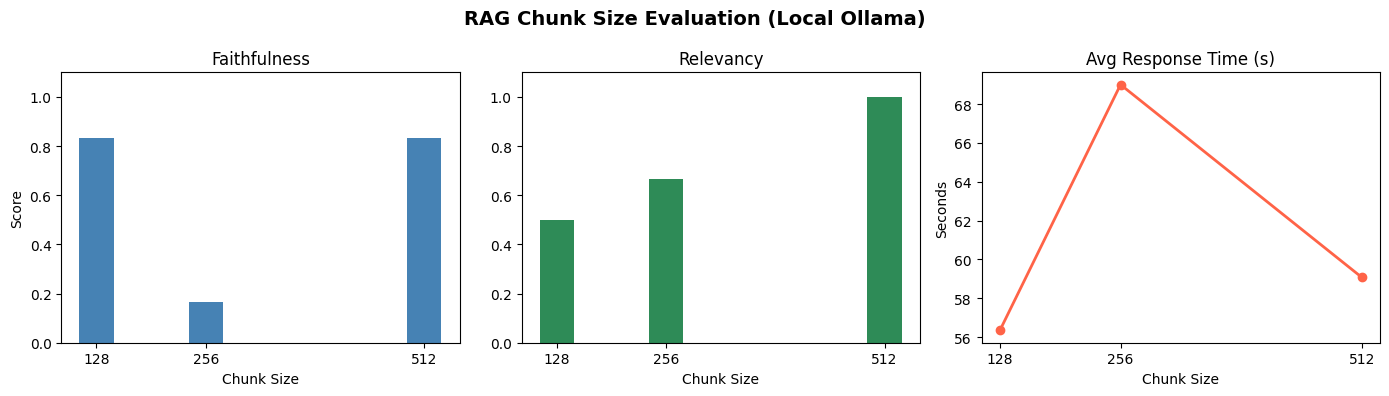

📊 Chart saved as chunk_size_results.png


In [25]:
import matplotlib.pyplot as plt

sizes      = [r["chunk_size"] for r in results]
faith_vals = [r["avg_faithfulness"] for r in results]
relev_vals = [r["avg_relevancy"] for r in results]
time_vals  = [r["avg_response_time"] for r in results]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle("RAG Chunk Size Evaluation (Local Ollama)", fontsize=14, fontweight="bold")

axes[0].bar(sizes, faith_vals, color="steelblue", width=40)
axes[0].set_title("Faithfulness")
axes[0].set_xlabel("Chunk Size")
axes[0].set_ylabel("Score")
axes[0].set_ylim(0, 1.1)
axes[0].set_xticks(sizes)

axes[1].bar(sizes, relev_vals, color="seagreen", width=40)
axes[1].set_title("Relevancy")
axes[1].set_xlabel("Chunk Size")
axes[1].set_ylim(0, 1.1)
axes[1].set_xticks(sizes)

axes[2].plot(sizes, time_vals, marker="o", color="tomato", linewidth=2)
axes[2].set_title("Avg Response Time (s)")
axes[2].set_xlabel("Chunk Size")
axes[2].set_ylabel("Seconds")
axes[2].set_xticks(sizes)

plt.tight_layout()
plt.savefig("chunk_size_results.png", dpi=150)
plt.show()
print("📊 Chart saved as chunk_size_results.png")

## 💡 Interpretation Guide

| Metric | What it means | Want |
|---|---|---|
| **Faithfulness** | Answer is grounded in retrieved context | High ✅ |
| **Relevancy** | Retrieved chunks are relevant to the query | High ✅ |
| **Response Time** | How fast the pipeline answers | Low ✅ |

**General rule of thumb:**
- `128–256` tokens → good for precise factual Q&A
- `512–1024` tokens → better for complex, context-heavy questions
- Pick the smallest chunk size that keeps faithfulness & relevancy high
